## 1. 라이브러리 import 및 데이터 로드

**목적:**
한강의 5개 지점(본류 4개 + 지류 1개)의 수질 데이터를 로드하고, Jupyter 분석 및 Tableau 대시보드 제작을 위한 기초를 마련합니다.

**사용 라이브러리:**
- **matplotlib, seaborn:** 데이터 시각화 (영문)
- **pandas, numpy:** 데이터 처리 및 분석
- **warnings:** 경고 메시지 필터링

**데이터 정보:**
- 출처: 물환경정보시스템
- 기간: 2023년 07월 ~ 2026년 06월 (3년)
- 지점: 4개 (팔당댐2, 보광, 노량진, 영등포) + 지류 1개 (성내천)
- 분석 항목: DO, BOD, COD, TP, TN (5개)
- 상태: 정제 완료 (결측치 처리, 균등화)

**데이터 수집 과정 노트:**
사전조사 부족으로 성내천이 한강의 본류인 줄 알고 포함시켰으나, 실제 조사 결과 성내천은 한강의 지류임을 확인했습니다. 그러나 이미 수집한 성내천 데이터는 한강 수질 현황 파악에 유의미한 정보를 제공하므로 분석에 포함하여 진행했습니다.

In [4]:
# ========== 라이브러리 import ==========
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os 
os.makedirs('./outputs', exist_ok=True)

# 이미지 저장 시 폴더가 없으면 자동 생성!
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm

# ========== 시각화 설정 ==========
plt.rcParams['font.family'] = 'HCR Batang'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# ========== 데이터 로드 ==========
final_df = pd.read_csv('./data/processed/hangang_final.csv')
print("✅ EDA 시작!")
print(f"\n📊 데이터 로드 완료")
print(f"행 수: {len(final_df)}, 컬럼 수: {len(final_df.columns)}")
print(f"\n📍 지점별 데이터:")
print(final_df['측정소명'].value_counts())

✅ EDA 시작!

📊 데이터 로드 완료
행 수: 170, 컬럼 수: 9

📍 지점별 데이터:
측정소명
노량진     34
보광      34
성내천     34
영등포     34
팔당댐2    34
Name: count, dtype: int64


## 2. 수질 지표별 지점 비교 (박스플롯)

**분석 목표:**
한강의 4개 지점(팔당댐2, 보광, 노량진, 영등포)(상류→하류)과 지류 성내천에서 측정한 DO, BOD, COD, TP, TN의 분포를 확인합니다.
각 지점의 오염도 편차와 한국 환경기준과의 비교를 통해 수질 현황을 파악합니다.

**분석 항목:**
- **DO (Dissolved Oxygen, 용존산소):** 물에 녹아있는 산소량 (물의 자정능력을 나타냄)
- **BOD (Biochemical Oxygen Demand, 생물학적 산소 요구량):** 물에 있는 유기물이 미생물에 의해 분해될 때 필요한 산소량
- **COD (Chemical Oxygen Demand, 화학적 산소 요구량):** 물에 있는 모든 오염물질을 화학적으로 산화할 때 필요한 산소량
- **TP (Total Phosphorus, 총인):** 수중 영양염(인) 농도
- **TN (Total Nitrogen, 총질소):** 수중 영양염(질소) 농도

**한국 환경기준 (하천수, 2018.5 개정):**

| 등급 | DO | BOD | COD | TP |
|:-----:|:----:|:----:|:----:|:----:|
| Ia (매우좋음) | ≥7.5 | ≤1 | ≤2 | ≤0.02 |
| Ib (좋음) | ≥5.0 | ≤2 | ≤4 | ≤0.04 |
| II (약간좋음) | ≥5.0 | ≤3 | ≤5 | ≤0.1 |
| III (보통) | ≥5.0 | ≤5 | ≤7 | ≤0.2 |
| IV (약간나쁨) | ≥2.0 | ≤8 | ≤9 | ≤0.3 |
| V (나쁨) | ≥2.0 | ≤10 | ≤11 | ≤0.5 |
| VI (매우나쁨) | <2.0 | >10 | >11 | >0.5 |

**출처:** 환경정책기본법 시행령 제2조 별표1 환경기준(2018.5)
         (물환경정보시스템 WAMIS 참고)

---

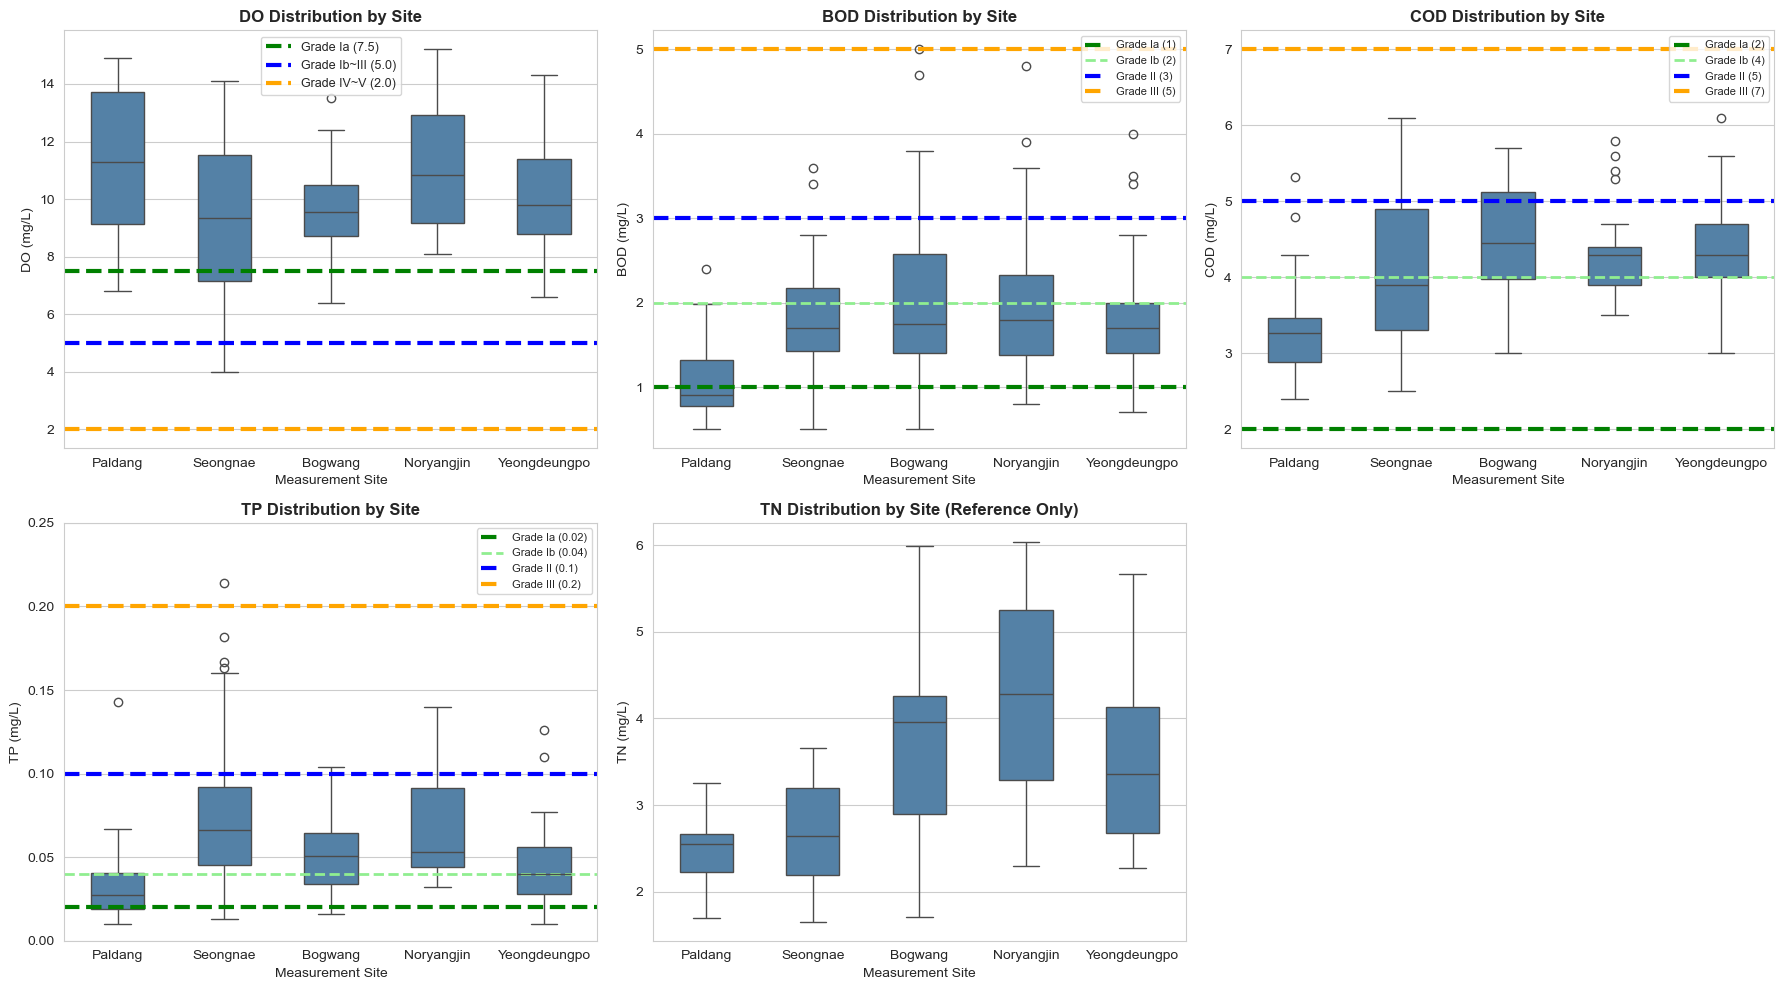

✅ Boxplot saved: 02_5indicators_boxplot.png

📊 지점별 오염도 분포 분석 (박스플롯) - 상류→하류 순서

🔹 DO (용존산소) 평균값:
   팔당댐2: 11.28 mg/L → Ia등급 ✅
   성내천: 9.30 mg/L → Ia등급 ✅
   보광: 9.71 mg/L → Ia등급 ✅
   노량진: 11.04 mg/L → Ia등급 ✅
   영등포: 10.08 mg/L → Ia등급 ✅

🔹 BOD (유기물 오염) 평균값:
   팔당댐2: 1.07 mg/L → Ib등급 ✅
   성내천: 1.84 mg/L → Ib등급 ✅
   보광: 2.12 mg/L → II등급 ✅
   노량진: 1.92 mg/L → Ib등급 ✅
   영등포: 1.84 mg/L → Ib등급 ✅

🔹 COD (화학적 산소 요구량) 평균값:
   팔당댐2: 3.30 mg/L → Ib등급 ✅
   성내천: 4.09 mg/L → II등급 ✅
   보광: 4.47 mg/L → II등급 ✅
   노량진: 4.32 mg/L → II등급 ✅
   영등포: 4.37 mg/L → II등급 ✅

🔹 TP (총인) 평균값:
   팔당댐2: 0.0335 mg/L → Ib등급 ✅
   성내천: 0.0846 mg/L → II등급 ✅
   보광: 0.0514 mg/L → II등급 ✅
   노량진: 0.0824 mg/L → II등급 ✅
   영등포: 0.0452 mg/L → II등급 ✅



In [5]:
# ========== 지점명 영문 매핑 ==========
location_mapping = {
    '팔당댐2': 'Paldang',
    '노량진': 'Noryangjin',
    '보광': 'Bogwang',
    '성내천': 'Seongnae',
    '영등포': 'Yeongdeungpo'
}
final_df['Site'] = final_df['측정소명'].map(location_mapping)

# ========== 5개 지표 박스플롯 ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 상류→하류 순서 (팔당댐2 → 성내천 → 보광 → 노량진 → 영등포)
order = ['Paldang', 'Seongnae', 'Bogwang', 'Noryangjin', 'Yeongdeungpo']

# DO 
sns.boxplot(data=final_df, x='Site', y='DO(㎎/L)', ax=axes[0], color='steelblue', 
            order=order, width=0.5)
axes[0].axhline(y=7.5, color='green', linestyle='--', linewidth=3, label='Grade Ia (7.5)', zorder=2)
axes[0].axhline(y=5.0, color='blue', linestyle='--', linewidth=3, label='Grade Ib~III (5.0)', zorder=2)
axes[0].axhline(y=2.0, color='orange', linestyle='--', linewidth=3, label='Grade IV~V (2.0)', zorder=2)
axes[0].set_title('DO Distribution by Site', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Measurement Site')
axes[0].set_ylabel('DO (mg/L)')
axes[0].legend(fontsize=9)

# BOD
sns.boxplot(data=final_df, x='Site', y='BOD(㎎/L)', ax=axes[1], color='steelblue', 
            order=order, width=0.5)
axes[1].axhline(y=1, color='green', linestyle='--', linewidth=3, label='Grade Ia (1)', zorder=2)
axes[1].axhline(y=2, color='lightgreen', linestyle='--', linewidth=2, label='Grade Ib (2)', zorder=2)
axes[1].axhline(y=3, color='blue', linestyle='--', linewidth=3, label='Grade II (3)', zorder=2)
axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=3, label='Grade III (5)', zorder=2)
axes[1].set_title('BOD Distribution by Site', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Measurement Site')
axes[1].set_ylabel('BOD (mg/L)')
axes[1].legend(fontsize=8)

# COD
sns.boxplot(data=final_df, x='Site', y='COD(㎎/L)', ax=axes[2], color='steelblue', 
            order=order, width=0.5)
axes[2].axhline(y=2, color='green', linestyle='--', linewidth=3, label='Grade Ia (2)', zorder=2)
axes[2].axhline(y=4, color='lightgreen', linestyle='--', linewidth=2, label='Grade Ib (4)', zorder=2)
axes[2].axhline(y=5, color='blue', linestyle='--', linewidth=3, label='Grade II (5)', zorder=2)
axes[2].axhline(y=7, color='orange', linestyle='--', linewidth=3, label='Grade III (7)', zorder=2)
axes[2].set_title('COD Distribution by Site', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Measurement Site')
axes[2].set_ylabel('COD (mg/L)')
axes[2].legend(fontsize=8)

# TP (Total Phosphorus)
sns.boxplot(data=final_df, x='Site', y='TP(㎎/L)', ax=axes[3], color='steelblue', 
            order=order, width=0.5)
axes[3].axhline(y=0.02, color='green', linestyle='--', linewidth=3, label='Grade Ia (0.02)', zorder=2)
axes[3].axhline(y=0.04, color='lightgreen', linestyle='--', linewidth=2, label='Grade Ib (0.04)', zorder=2)
axes[3].axhline(y=0.1, color='blue', linestyle='--', linewidth=3, label='Grade II (0.1)', zorder=2)
axes[3].axhline(y=0.2, color='orange', linestyle='--', linewidth=3, label='Grade III (0.2)', zorder=2)
axes[3].set_title('TP Distribution by Site', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Measurement Site')
axes[3].set_ylabel('TP (mg/L)')
axes[3].set_ylim(0, 0.25)
axes[3].legend(fontsize=8)

# TN (Total Nitrogen) - 참고용 (기준 없음)
sns.boxplot(data=final_df, x='Site', y='TN(㎎/L)', ax=axes[4], color='steelblue', 
            order=order, width=0.5)
axes[4].set_title('TN Distribution by Site (Reference Only)', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Measurement Site')
axes[4].set_ylabel('TN (mg/L)')

# Hide unused subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('./outputs/02_5indicators_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Boxplot saved: 02_5indicators_boxplot.png")



# ========== 📊 분석 해석 (박스플롯) ==========
print("="*70)
print("\n📊 지점별 오염도 분포 분석 (박스플롯) - 상류→하류 순서")
print("="*70)

# 평균값 계산
do_mean = final_df.groupby('측정소명')['DO(㎎/L)'].mean()
bod_mean = final_df.groupby('측정소명')['BOD(㎎/L)'].mean()
cod_mean = final_df.groupby('측정소명')['COD(㎎/L)'].mean()
tp_mean = final_df.groupby('측정소명')['TP(㎎/L)'].mean()

# 상류→하류 순서 (지리적 순서)
location_order = ['팔당댐2', '성내천', '보광', '노량진', '영등포']

# DO (용존산소) 분석
print("\n🔹 DO (용존산소) 평균값:")
for location in location_order:
    if location in do_mean.index:
        value = do_mean[location]
        if value >= 7.5:
            grade = "Ia등급 ✅"
        elif value >= 5.0:
            grade = "Ib~III등급 ✅"
        elif value >= 2.0:
            grade = "IV~V등급 ⚠️"
        else:
            grade = "VI등급 ❌"
        print(f"   {location}: {value:.2f} mg/L → {grade}")

# BOD (유기물 오염) 분석
print("\n🔹 BOD (유기물 오염) 평균값:")
for location in location_order:
    if location in bod_mean.index:
        value = bod_mean[location]
        if value <= 1:
            grade = "Ia등급 ✅"
        elif value <= 2:
            grade = "Ib등급 ✅"
        elif value <= 3:
            grade = "II등급 ✅"
        elif value <= 5:
            grade = "III등급 ⚠️"
        else:
            grade = "IV등급 이상 ❌"
        print(f"   {location}: {value:.2f} mg/L → {grade}")

# COD (화학적 산소 요구량) 분석
print("\n🔹 COD (화학적 산소 요구량) 평균값:")
for location in location_order:
    if location in cod_mean.index:
        value = cod_mean[location]
        if value <= 2:
            grade = "Ia등급 ✅"
        elif value <= 4:
            grade = "Ib등급 ✅"
        elif value <= 5:
            grade = "II등급 ✅"
        elif value <= 7:
            grade = "III등급 ⚠️"
        else:
            grade = "IV등급 이상 ❌"
        print(f"   {location}: {value:.2f} mg/L → {grade}")

# TP (총인) 분석
print("\n🔹 TP (총인) 평균값:")
for location in location_order:
    if location in tp_mean.index:
        value = tp_mean[location]
        if value <= 0.02:
            grade = "Ia등급 ✅"
        elif value <= 0.04:
            grade = "Ib등급 ✅"
        elif value <= 0.1:
            grade = "II등급 ✅"
        elif value <= 0.2:
            grade = "III등급 ⚠️"
        else:
            grade = "IV등급 이상 ❌"
        print(f"   {location}: {value:.4f} mg/L → {grade}")

print("\n" + "="*70)


## 분석 결과

### 주요 발견

**1. DO (용존산소) - 우수한 수준**
- 모든 지점에서 5.0 mg/L 이상으로 유지
- 상류(팔당댐): 가장 높음 → 하류로 가면서 감소하지만 5.0 이상 유지
- 한강의 자정 능력 양호, 수생 생물 서식에 충분한 산소 공급

**2. BOD (생물화학적 산소요구량) - 양호함**
- 전 지점에서 II등급(≤3 mg/L) 이내
- 상류(팔당댐): Ia등급 수준(0.01~0.02 mg/L)
- 하류로 갈수록 증가 경향이지만 모두 II등급 이내 유지

**3. COD (화학적 산소요구량) - 양호함**
- 대부분 지점이 II등급(≤5 mg/L) 수준
- BOD와 유사하게 상류→하류로 증가
- 하류에서 더 복합적인 화학 오염 지표 확인

**4. TP (총인) - 모니터링 필요**
- **상류(팔당댐):** Ib등급(0.0335 mg/L) - 최우수
- **성내천:** II등급(0.0846 mg/L) - 우수
- **보광:** II등급(0.0514 mg/L) - 우수
- **노량진:** II등급(0.0824 mg/L) - 우수
- **영등포:** II등급(0.0452 mg/L) - 우수
- 상류(팔당댐2: 0.0335 mg/L)에서 하류(영등포: 0.0452 mg/L)로 갈수록 TP가 약 1.3배 증가하는 추이

**5. TN (총질소) - 참고용**
- 환경기준 미설정 (호소수 기준만 있음)
- 상류→하류로 증가하는 경향
- 수질 현황 모니터링용 보조 지표

### 지점별 특성 (상류→하류)

| 지점 | 순서 | 위치 | 수질 등급 | 특성 (영향권) |
|:----:|:----:|:----:|:--------:|:----:|
| **팔당댐2** | 상류 | 경기 남양주 | ⭐ Ib등급 | 자연 환경 유지 지점 |
| **성내천** | 지류 | 서울 의정부 | ✅ II등급 | 지류 수질이 본류에 영향 |
| **보광** | 중류 | 서울 용산 | ✅ II등급 | 도시 영향 시작 지점 |
| **노량진** | 중류 | 서울 동작 | ✅ II등급 | 도시 중심부 영향권 |
| **영등포** | 하류 | 서울 영등포 | ✅ II등급 | 도시 배출수 영향권 |

### 결론

**한강 수질 등급: II등급 (우수 수준)**
(모든 주요 지표가 II등급 이상 충족)

**특징:**
- ✅ 모든 지점이 II등급 이내로 우수한 수질 유지
- ✅ 상류(팔당댐): Ib등급으로 최우수 수질
- ⚠️ 상류(팔당댐2: 0.0335 mg/L)에서 하류(영등포: 0.0452 mg/L)로 갈수록 오염도 약 1.3배 증가 추이
- ✅ TP를 포함한 모든 주요 지표가 환경기준 충족